In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib 
import seaborn as sns

In [2]:
df = pd.read_csv('Quality_of_Life.csv')

In [3]:
df.shape #how many rows and columns

(236, 19)

In [4]:
df.isna().sum() #Shows how many NA values there are for each column

country                                0
Purchasing Power Value                 0
Purchasing Power Category             46
Safety Value                           0
Safety Category                        2
Health Care Value                      0
Health Care Category                  15
Climate Value                          0
Climate Category                     122
Cost of Living Value                   0
Cost of Living Category               45
Property Price to Income Value         0
Property Price to Income Category     21
Traffic Commute Time Value             0
Traffic Commute Time Category         29
Pollution Value                        0
Pollution Category                    10
Quality of Life Value                  0
Quality of Life Category             122
dtype: int64

In [5]:
(df == 0).sum() #Some columns have 0s as placeholders instead of NAs 

country                                0
Purchasing Power Value                46
Purchasing Power Category              0
Safety Value                           2
Safety Category                        0
Health Care Value                     15
Health Care Category                   0
Climate Value                        122
Climate Category                       0
Cost of Living Value                  45
Cost of Living Category                0
Property Price to Income Value         0
Property Price to Income Category      0
Traffic Commute Time Value            34
Traffic Commute Time Category          0
Pollution Value                       11
Pollution Category                     0
Quality of Life Value                  0
Quality of Life Category               0
dtype: int64

In [6]:
df.describe(include='all') #There's a negative value for climate value

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
count,236,236.000000,190,236.000000,234,236.000000,221,236.000000,114,236.000000,191,236,215,236.000000,207,236.000000,226,236,114
unique,236,NaN,5,NaN,5,NaN,5,NaN,4,NaN,5,204,5,NaN,5,NaN,5,113,5
top,Afghanistan,NaN,'Very Low',NaN,'Moderate',NaN,'High',NaN,'Very High',NaN,'Very Low',0.0,'Very High',NaN,'Very Low',NaN,'High',0.0,'Very High'
freq,1,NaN,63,NaN,100,NaN,93,NaN,58,NaN,88,22,74,NaN,62,NaN,84,122,33
mean,NaN,55.573305,NaN,55.274449,NaN,54.731568,NaN,37.598178,NaN,37.526314,NaN,NaN,NaN,28.492966,NaN,54.266186,NaN,NaN,NaN
std,NaN,52.008245,NaN,16.914298,NaN,20.607381,NaN,40.851542,NaN,26.026565,NaN,NaN,NaN,17.347242,NaN,25.853695,NaN,NaN,NaN
min,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,-3.540000,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN
25%,NaN,16.340000,NaN,43.857500,NaN,45.807500,NaN,0.000000,NaN,24.550000,NaN,NaN,NaN,17.100000,NaN,35.700000,NaN,NaN,NaN
50%,NaN,42.930000,NaN,54.635000,NaN,57.150000,NaN,0.000000,NaN,36.895000,NaN,NaN,NaN,29.845000,NaN,59.765000,NaN,NaN,NaN
75%,NaN,85.940000,NaN,68.132500,NaN,68.447500,NaN,79.332500,NaN,51.090000,NaN,NaN,NaN,38.870000,NaN,73.740000,NaN,NaN,NaN


In [7]:
df.info() #Some columns that should be floats are objects, like Quality of Life Value & Property Price to Income Value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            236 non-null    object 
 1   Purchasing Power Value             236 non-null    float64
 2   Purchasing Power Category          190 non-null    object 
 3   Safety Value                       236 non-null    float64
 4   Safety Category                    234 non-null    object 
 5   Health Care Value                  236 non-null    float64
 6   Health Care Category               221 non-null    object 
 7   Climate Value                      236 non-null    float64
 8   Climate Category                   114 non-null    object 
 9   Cost of Living Value               236 non-null    float64
 10  Cost of Living Category            191 non-null    object 
 11  Property Price to Income Value     236 non-null    object 

In [8]:
df.head(10) #Some columns have extra characters like in Quality of Life Value
#and the categories have extra ' so it just looks messy
#Instead of NAs there's None, or 0s 

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',0.00,NaN,21.08,'Very Low',7.8,'Low',56.17,'Very High',84.44,'Very High',0.0,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',0.00,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',0.0,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',': 104.16','Low'
3,Alderney,0.00,NaN,83.79,'Very High',100.00,'Very High',0.00,NaN,0.00,NaN,0.0,NaN,5.00,'Very Low',1.72,'Very Low',0.0,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.7,'Very High',45.09,'High',63.87,'High',': 98.83','Very Low'
5,American Samoa,0.00,NaN,54.41,'Moderate',0.00,NaN,0.00,NaN,0.00,NaN,0.0,NaN,100.00,'Very High',78.45,'High',0.0,NaN
6,Andorra,121.14,'Very High',84.71,'Very High',75.56,'High',0.00,NaN,48.09,'Low',9.03,'Moderate',13.33,'Very Low',22.98,'Low',0.0,NaN
7,Angola,224.46,'Very High',33.71,'Low',36.58,'Low',0.00,NaN,42.57,'Low',8.01,'Moderate',65.43,'Very High',92.07,'Very High',0.0,NaN
8,Anguilla,0.00,NaN,75.44,'High',77.08,'High',0.00,NaN,0.00,NaN,1.8399999999999999,'Very Low',0.00,NaN,0.00,NaN,0.0,NaN
9,Antigua And Barbuda,0.00,NaN,42.86,'Moderate',30.56,'Low',0.00,NaN,0.00,NaN,0.0,NaN,35.00,'Moderate',43.10,'Moderate',0.0,NaN


In [9]:
df["Quality of Life Value"].head(25) #Extra characters,they aren't simple strings

0            0.0
1            0.0
2     ': 104.16'
3            0.0
4      ': 98.83'
5            0.0
6            0.0
7            0.0
8            0.0
9            0.0
10    ': 115.06'
11    ': 116.56'
12           0.0
13    ': 190.69'
14    ': 192.07'
15    ': 113.51'
16           0.0
17    ': 158.68'
18     ': 74.51'
19           0.0
20    ': 127.48'
21    ': 168.52'
22           0.0
23           0.0
24           0.0
Name: Quality of Life Value, dtype: object

In [10]:
df['Property Price to Income Value'].head(10) #Says 0 NAs, but some have 0 as a placeholder and a long number 1.8399, also an object

0                   7.8
1                  5.33
2                 14.88
3                   0.0
4                  21.7
5                   0.0
6                  9.03
7                  8.01
8    1.8399999999999999
9                   0.0
Name: Property Price to Income Value, dtype: object

In [11]:
#Clean Quality of Life Value column
df['Quality of Life Value'] = (
    df['Quality of Life Value']
      .astype(str) #make everything a string in case it isnt so we can clean it
      .str.replace("'", "") #remove single quotes '
      .str.replace(":", "") #remove colons :
      .str.replace(" ", "") #remove any spaces
)
    
df['Quality of Life Value'].head(25)

0        0.0
1        0.0
2     104.16
3        0.0
4      98.83
5        0.0
6        0.0
7        0.0
8        0.0
9        0.0
10    115.06
11    116.56
12       0.0
13    190.69
14    192.07
15    113.51
16       0.0
17    158.68
18     74.51
19       0.0
20    127.48
21    168.52
22       0.0
23       0.0
24       0.0
Name: Quality of Life Value, dtype: object

In [12]:
#Simarily clean Property Price to Income Value
df['Property Price to Income Value'] = (
    df['Property Price to Income Value']
      .astype(str) #make everything a string in case it isnt so we can clean it
      .str.replace("'", "") #remove single quotes '
      .str.replace(":", "") #remove colons 
      .str.replace(",", "") #remove commas since I was eyeballing the csv file and saw it contained it
      .str.replace(" ", "")       #remove spaces
)
df['Property Price to Income Value'].head(25)

0                    7.8
1                   5.33
2                  14.88
3                    0.0
4                   21.7
5                    0.0
6                   9.03
7                   8.01
8     1.8399999999999999
9                    0.0
10                 20.05
11                 20.95
12                  5.32
13                  8.25
14                 11.76
15                 15.24
16                  5.32
17                   4.9
18                 12.26
19                 14.67
20                 12.79
21                  6.82
22                  6.06
23                   0.0
24                  6.85
Name: Property Price to Income Value, dtype: object

In [13]:
df[df['country'] == 'Niger']
#Confirmed '2,746.00' is now 2746.00

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
152,Niger,7.04,'Very Low',33.38,'Low',30.56,'Low',0.0,NaN,132.99,'Very High',2746.00,'Very High',20.0,'Very Low',63.79,'High',0.0,NaN


In [14]:
#Convert columns that end with values from strings to numberical values (objects to floats) since these should be numbers we can use
value_cols = [c for c in df.columns if c.endswith("Value")]

df[value_cols] = df[value_cols].apply(pd.to_numeric, errors='coerce')

#Round to 2 decimals after it's now a number to deal with long numbers so it looks cleaner
df[value_cols] = df[value_cols].round(2)

df[value_cols].dtypes

Purchasing Power Value            float64
Safety Value                      float64
Health Care Value                 float64
Climate Value                     float64
Cost of Living Value              float64
Property Price to Income Value    float64
Traffic Commute Time Value        float64
Pollution Value                   float64
Quality of Life Value             float64
dtype: object

In [15]:
df['Property Price to Income Value'].head(25)

0      7.80
1      5.33
2     14.88
3      0.00
4     21.70
5      0.00
6      9.03
7      8.01
8      1.84
9      0.00
10    20.05
11    20.95
12     5.32
13     8.25
14    11.76
15    15.24
16     5.32
17     4.90
18    12.26
19    14.67
20    12.79
21     6.82
22     6.06
23     0.00
24     6.85
Name: Property Price to Income Value, dtype: float64

In [16]:
df[df['Climate Value']<0] #Climate Value is negative

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
139,Mongolia,31.73,'Very Low',47.53,'Moderate',51.63,'Moderate',-3.54,'Low',30.68,'Very Low',16.08,'Very High',31.42,'Low',87.82,'Very High',62.52,'Very Low'


In [17]:
df.loc[df['Climate Value'] < 0, 'Climate Value'] = np.nan
df[df['country'] == 'Mongolia'] #Climate Value is now NA, assuming negative is bad data and not a valid measure

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
139,Mongolia,31.73,'Very Low',47.53,'Moderate',51.63,'Moderate',NaN,'Low',30.68,'Very Low',16.08,'Very High',31.42,'Low',87.82,'Very High',62.52,'Very Low'


In [18]:
df['Climate Value'].head(20) #Just from eyeballing, climate values do not go as low to single digits, so 
#Im going to treat this as a possible error

0      0.00
1      0.00
2     86.43
3      0.00
4     94.82
5      0.00
6      0.00
7      0.00
8      0.00
9      0.00
10    98.28
11    63.42
12     0.00
13    93.80
14    77.40
15    91.40
16     0.00
17    64.31
18    71.29
19     0.00
Name: Climate Value, dtype: float64

In [19]:
df.head(10)

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',0.00,NaN,21.08,'Very Low',7.80,'Low',56.17,'Very High',84.44,'Very High',0.00,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',0.00,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',0.00,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',104.16,'Low'
3,Alderney,0.00,NaN,83.79,'Very High',100.00,'Very High',0.00,NaN,0.00,NaN,0.00,NaN,5.00,'Very Low',1.72,'Very Low',0.00,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.70,'Very High',45.09,'High',63.87,'High',98.83,'Very Low'
5,American Samoa,0.00,NaN,54.41,'Moderate',0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,100.00,'Very High',78.45,'High',0.00,NaN
6,Andorra,121.14,'Very High',84.71,'Very High',75.56,'High',0.00,NaN,48.09,'Low',9.03,'Moderate',13.33,'Very Low',22.98,'Low',0.00,NaN
7,Angola,224.46,'Very High',33.71,'Low',36.58,'Low',0.00,NaN,42.57,'Low',8.01,'Moderate',65.43,'Very High',92.07,'Very High',0.00,NaN
8,Anguilla,0.00,NaN,75.44,'High',77.08,'High',0.00,NaN,0.00,NaN,1.84,'Very Low',0.00,NaN,0.00,NaN,0.00,NaN
9,Antigua And Barbuda,0.00,NaN,42.86,'Moderate',30.56,'Low',0.00,NaN,0.00,NaN,0.00,NaN,35.00,'Moderate',43.10,'Moderate',0.00,NaN


In [20]:
df = df.replace(0, np.nan) #Some have 0 as a placeholder, but this updates to NA so we can see how many are truly missing
df.head()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',NaN,NaN,21.08,'Very Low',7.80,'Low',56.17,'Very High',84.44,'Very High',NaN,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',NaN,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',NaN,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',104.16,'Low'
3,Alderney,NaN,NaN,83.79,'Very High',100.00,'Very High',NaN,NaN,NaN,NaN,NaN,NaN,5.00,'Very Low',1.72,'Very Low',NaN,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.70,'Very High',45.09,'High',63.87,'High',98.83,'Very Low'


In [21]:
df[df["Purchasing Power Value"].isna()] #Before Purchasing power value had 0 NA, but now we see it actually does once updated

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
3,Alderney,NaN,NaN,83.79,'Very High',100.00,'Very High',NaN,NaN,NaN,NaN,NaN,NaN,5.00,'Very Low',1.72,'Very Low',NaN,NaN
5,American Samoa,NaN,NaN,54.41,'Moderate',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.00,'Very High',78.45,'High',NaN,NaN
8,Anguilla,NaN,NaN,75.44,'High',77.08,'High',NaN,NaN,NaN,NaN,1.84,'Very Low',NaN,NaN,NaN,NaN,NaN,NaN
9,Antigua And Barbuda,NaN,NaN,42.86,'Moderate',30.56,'Low',NaN,NaN,NaN,NaN,NaN,NaN,35.00,'Moderate',43.10,'Moderate',NaN,NaN
22,Belize,NaN,NaN,47.47,'Moderate',47.37,'Moderate',NaN,NaN,NaN,NaN,6.06,'Low',12.75,'Very Low',52.80,'Moderate',NaN,NaN
23,Benin,NaN,NaN,62.16,'High',51.39,'Moderate',NaN,NaN,NaN,NaN,NaN,NaN,26.00,'Very Low',97.41,'Very High',NaN,NaN
27,Bonaire,NaN,NaN,62.95,'High',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,British Virgin Islands,NaN,NaN,59.31,'Moderate',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.10,'High',NaN,NaN
34,Burkina Faso,NaN,NaN,61.16,'High',49.31,'Moderate',NaN,NaN,NaN,NaN,1.25,'Very Low',50.00,'High',NaN,NaN,NaN,NaN
35,Burundi,NaN,NaN,43.44,'Moderate',34.44,'Low',NaN,NaN,NaN,NaN,20.67,'Very High',33.00,'Low',87.84,'Very High',NaN,NaN


In [22]:
category_cols = [c for c in df.columns if c.endswith("Category")]
#Look at every column name in the dataframe and keep only the ones that end with the word Category

for col in category_cols:
    df[col] = df[col].str.replace("'", "")
#For each column name in category_cols replace every ' character in all its values with an empty string
#Now 'Low' should be Low

In [23]:
df[category_cols] = df[category_cols].replace("None", pd.NA) #None is now Na

In [24]:
df.head()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,Very Low,25.33,Low,24.24,Low,NaN,NaN,21.08,Very Low,7.80,Low,56.17,Very High,84.44,Very High,NaN,NaN
1,Aland Islands,125.01,Very High,71.81,High,79.72,High,NaN,NaN,53.44,Low,5.33,Low,19.05,Very Low,18.05,Very Low,NaN,NaN
2,Albania,42.82,Low,55.52,Moderate,48.21,Moderate,86.43,Very High,40.85,Low,14.88,High,36.74,Moderate,77.25,High,104.16,Low
3,Alderney,NaN,NaN,83.79,Very High,100.00,Very High,NaN,NaN,NaN,NaN,NaN,NaN,5.00,Very Low,1.72,Very Low,NaN,NaN
4,Algeria,27.60,Very Low,47.54,Moderate,54.43,Moderate,94.82,Very High,25.31,Very Low,21.70,Very High,45.09,High,63.87,High,98.83,Very Low


In [25]:
df.isna().sum() #Updated true NAs sum

country                                0
Purchasing Power Value                46
Purchasing Power Category             46
Safety Value                           2
Safety Category                        2
Health Care Value                     15
Health Care Category                  15
Climate Value                        123
Climate Category                     122
Cost of Living Value                  45
Cost of Living Category               45
Property Price to Income Value        22
Property Price to Income Category     21
Traffic Commute Time Value            34
Traffic Commute Time Category         29
Pollution Value                       11
Pollution Category                    10
Quality of Life Value                125
Quality of Life Category             122
dtype: int64

In [26]:
all_cols = value_cols + category_cols

df = df.dropna(subset=all_cols, how='all')
#Drop those with no usable info

In [27]:
df.isna().sum() #only one was dropped 

country                                0
Purchasing Power Value                45
Purchasing Power Category             45
Safety Value                           1
Safety Category                        1
Health Care Value                     14
Health Care Category                  14
Climate Value                        122
Climate Category                     121
Cost of Living Value                  44
Cost of Living Category               44
Property Price to Income Value        21
Property Price to Income Category     20
Traffic Commute Time Value            33
Traffic Commute Time Category         28
Pollution Value                       10
Pollution Category                     9
Quality of Life Value                124
Quality of Life Category             121
dtype: int64

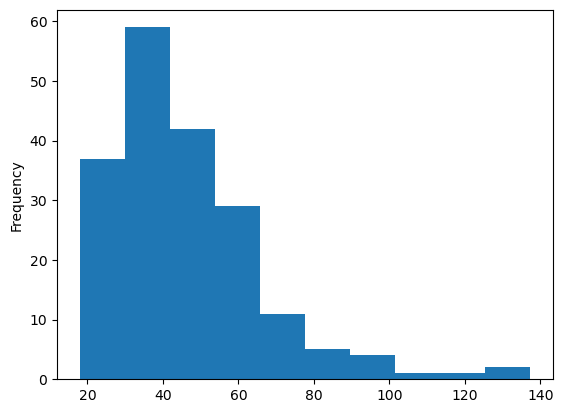

In [28]:
df['Cost of Living Value'].plot(kind='hist')
plt.show()

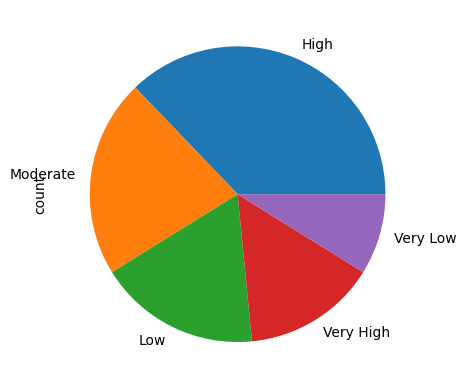

In [29]:
PollutionCategories = df['Pollution Category'].value_counts()
PollutionCategories.plot.pie()
plt.show()

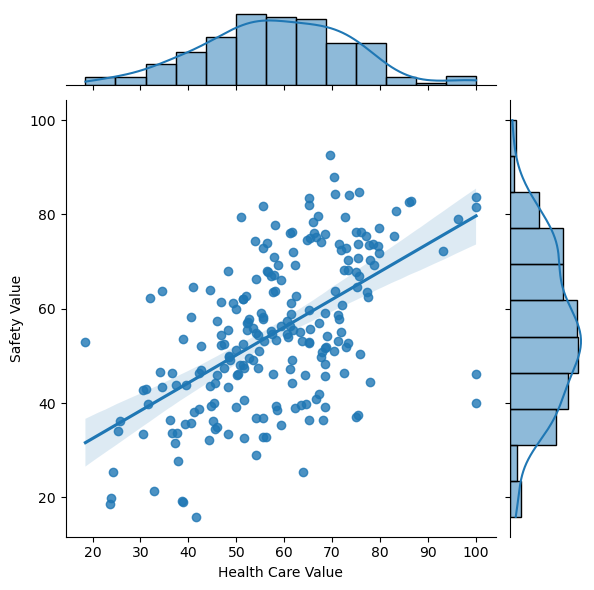

In [30]:
sns.jointplot(x=df['Health Care Value'], y=df['Safety Value'],kind='reg')
plt.show()

In [31]:
df.to_csv('Quality_of_Life_clean.csv', index=False) #To see the new clean file